# 🌳 Müşteri Segmentasyonu — Hiyerarşik Kümeleme / Customer Segmentation — Hierarchical Clustering

**🇹🇷 Türkçe:**
Bu notebook, klasik `mall_customers` veri setinde (200 müşteri: `Gender`, `Age`, `Annual Income`, `Spending Score`) **hiyerarşik kümeleme (Agglomerative Clustering)** uyguluyor. Önce bir dendrogram ile doğal küme sayısına dair sezgi kazanılıyor, ardından farklı özellik alt kümeleriyle ve farklı algoritmalarla (hiyerarşik kümeleme vs. K-Means) sonuçlar **silüet skoru**, **Davies-Bouldin** ve **Calinski-Harabasz** metrikleriyle karşılaştırılıyor.

**🇬🇧 English:**
This notebook applies **hierarchical (Agglomerative) clustering** to the classic `mall_customers` dataset (200 customers: `Gender`, `Age`, `Annual Income`, `Spending Score`). A dendrogram first gives intuition about the natural number of clusters, then results across different feature subsets and different algorithms (hierarchical clustering vs. K-Means) are compared using the **silhouette score**, **Davies-Bouldin**, and **Calinski-Harabasz** metrics.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme (`pandas`, `numpy`) ve görselleştirme (`matplotlib`, `seaborn`) için gerekli kütüphaneler yükleniyor.

**🇬🇧 English:**
Loading the libraries needed for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
`27-mall_customers.csv` okunuyor: 200 müşteri, `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)` kolonları. Etiket yok — bu denetimsiz bir kümeleme problemi.

**🇬🇧 English:**
`27-mall_customers.csv` is loaded: 200 customers, with columns `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`. There's no label — this is an unsupervised clustering problem.

In [2]:
df = pd.read_csv("../../Data/27-mall_customers.csv")

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`head()`, `info()` ve `describe()` ile veri inceleniyor: 200 satır, eksik değer yok, `Gender` dışında tüm kolonlar sayısal. `Age` 18-70, `Annual Income` 15-137 (bin $), `Spending Score` 1-99 aralığında.

**🇬🇧 English:**
The data is inspected with `head()`, `info()`, and `describe()`: 200 rows, no missing values, all columns numeric except `Gender`. `Age` ranges 18-70, `Annual Income` 15-137 (thousand $), `Spending Score` 1-99.

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 📊 3. Dağılım Görselleştirmesi / Distribution Visualization

**🇹🇷 Türkçe:**
Tekrar kullanılabilir bir `plot_all_histograms` yardımcı fonksiyonu tanımlanıyor: DataFrame'deki tüm sayısal kolonların histogramını (KDE eğrisiyle) tek bir figürde yan yana çiziyor. Bu fonksiyon, ölçekleme öncesi/sonrası dağılımları hızlıca karşılaştırmak için ileride tekrar çağrılıyor.

**🇬🇧 English:**
A reusable `plot_all_histograms` helper is defined: it plots a histogram (with a KDE curve) for every numeric column in a DataFrame, side by side in one figure. This helper is called again later to quickly compare distributions before/after scaling.

In [6]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

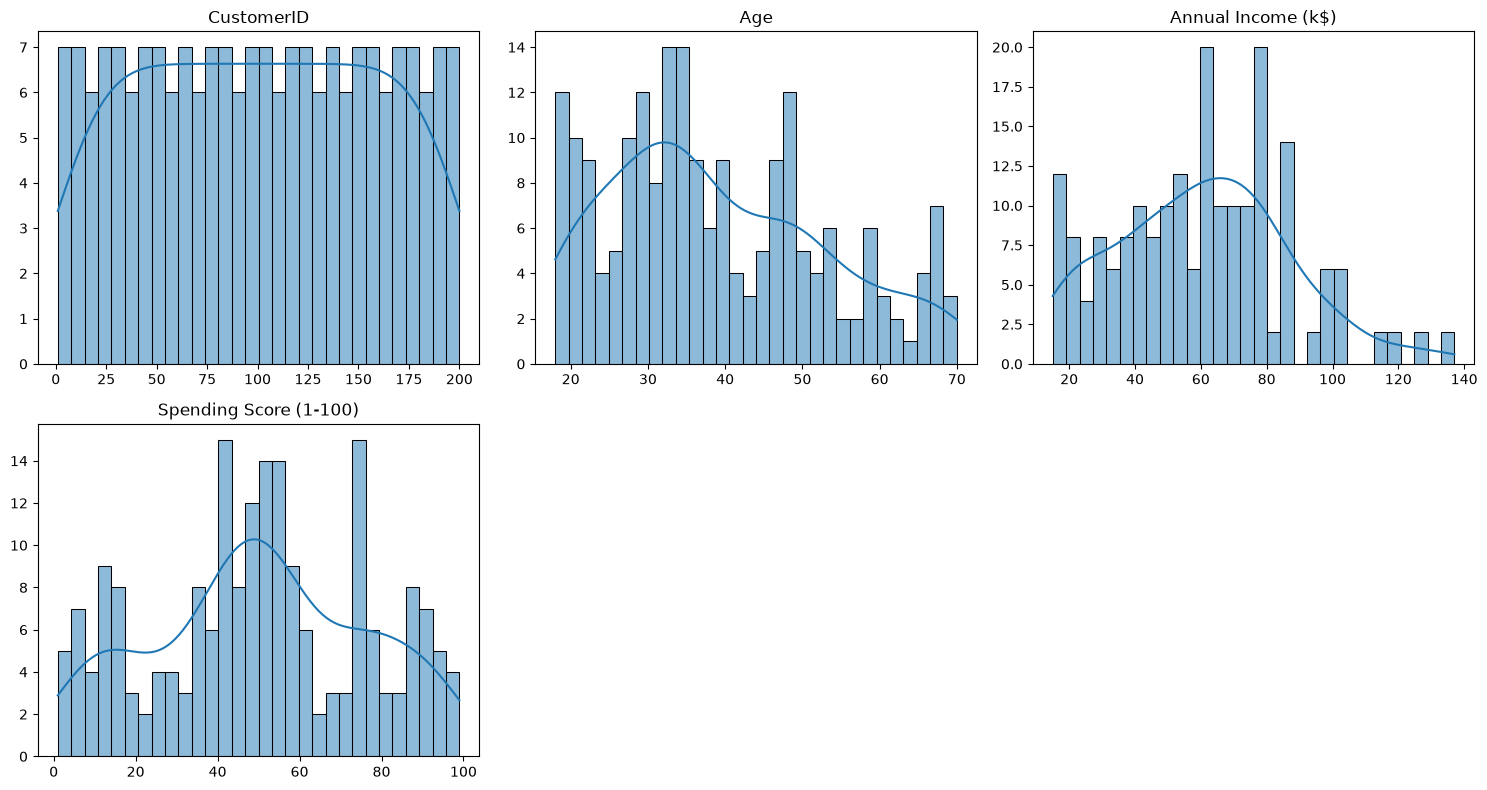

In [7]:
plot_all_histograms(df)

## 🔤 4. Kategorik Kolonu Kodlama / Encoding the Categorical Column

**🇹🇷 Türkçe:**
`Gender`'ın dağılımına (`value_counts`) bakılıyor: 112 kadın, 88 erkek — dengeli sayılabilecek bir dağılım. Kümeleme algoritmaları sayısal girdi beklediği için `LabelEncoder` ile `Gender` 0/1'e çevriliyor (Female=0, Male=1).

**🇬🇧 English:**
The distribution of `Gender` is checked (`value_counts`): 112 female, 88 male — a reasonably balanced split. Since clustering algorithms expect numeric input, `LabelEncoder` converts `Gender` to 0/1 (Female=0, Male=1).

In [8]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df['Gender'])

In [11]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


## 🗑️ 5. Kimlik Kolonunu Kaldırma / Dropping the ID Column

**🇹🇷 Türkçe:**
`CustomerID` sadece bir sıra numarası — hiçbir gerçek anlamı yok ve kümeleme algoritması onu bir "özellik" gibi kullanıp anlamsız uzaklıklar üretebilir. Bu yüzden `drop` ediliyor.

**🇬🇧 English:**
`CustomerID` is just a sequential number — it carries no real meaning, and a clustering algorithm could treat it as a "feature" and produce meaningless distances. So it's dropped.

In [12]:
df = df.drop('CustomerID', axis=1)

In [13]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## ⚖️ 6. Özellik Ölçekleme / Feature Scaling

**🇹🇷 Türkçe:**
Hiyerarşik kümeleme de uzaklık tabanlı olduğu için `MinMaxScaler` ile tüm kolonlar [0, 1] aralığına ölçekleniyor — yoksa `Annual Income` (15-137) gibi geniş aralıklı bir kolon, `Gender` (0-1) gibi dar aralıklı kolonların üzerinde haksız yere baskın gelirdi. Ölçekleme sonrası dağılımlar `plot_all_histograms` ile tekrar görselleştiriliyor — şekiller aynı kalıyor, sadece eksen aralığı [0,1]'e sıkışıyor.

**🇬🇧 English:**
Since hierarchical clustering is also distance-based, `MinMaxScaler` scales every column to [0, 1] — otherwise a wide-range column like `Annual Income` (15-137) would unfairly dominate over a narrow-range column like `Gender` (0-1). The distributions are visualized again with `plot_all_histograms` after scaling — the shapes stay the same, just squeezed into the [0,1] axis range.

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [16]:
df = pd.DataFrame(df_scaled, columns = df.columns)

In [17]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


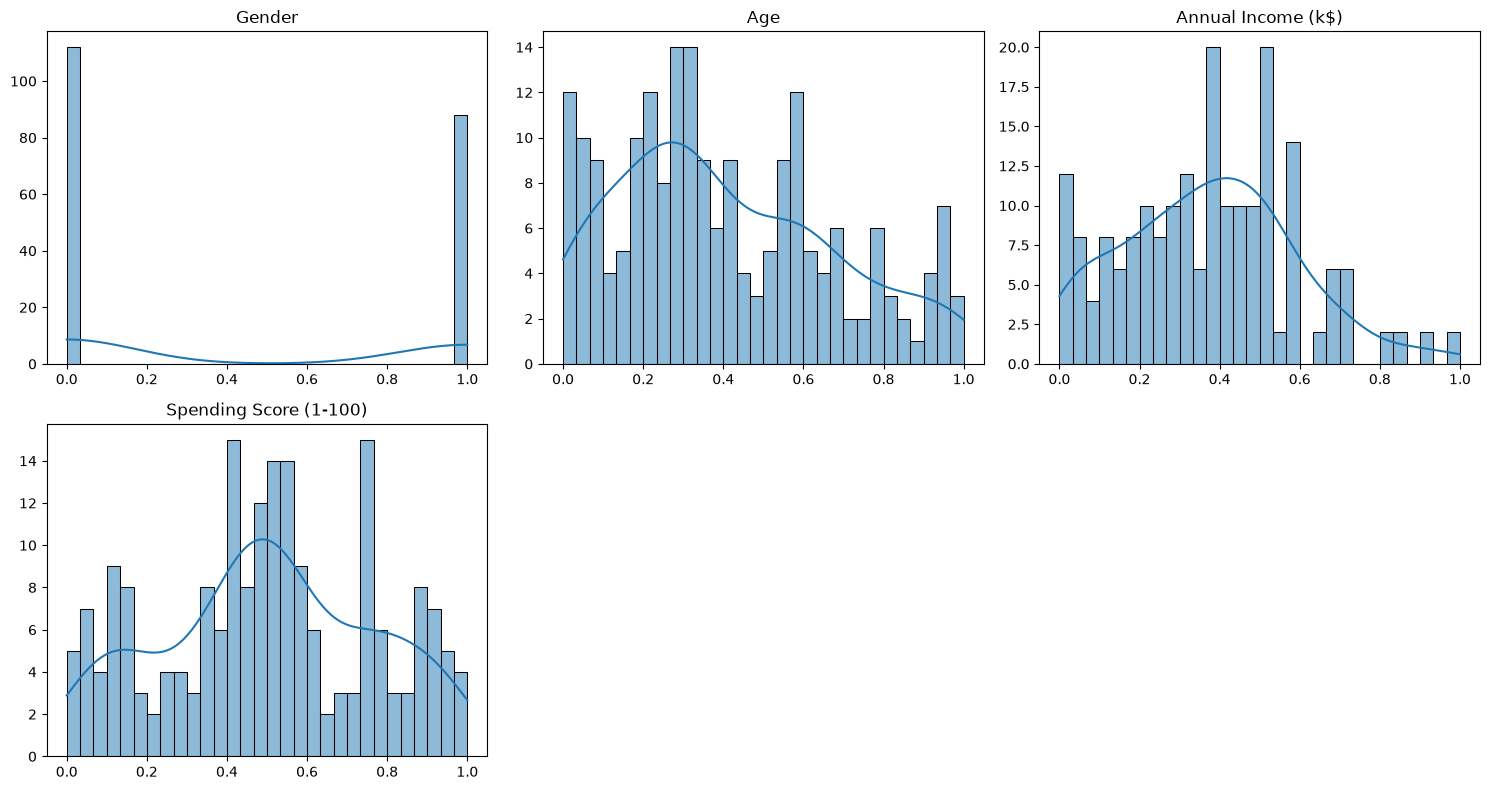

In [18]:
plot_all_histograms(df)

## 🌿 7. Dendrogram

**🇹🇷 Türkçe:**
`scipy`'nin `linkage` fonksiyonu (`method="ward"` — küme içi varyansı minimize eden birleştirme kriteri) ile hesaplanan bağlantı matrisi, bir dendrogram olarak çiziliyor. Dendrogramda en uzun düşey çizgilerin kesildiği yatay çizgi sayısı, makul bir küme sayısına dair sezgi veriyor — burada görsel olarak 4-5 civarı bir küme sayısı öne çıkıyor, aşağıdaki `AgglomerativeClustering(n_clusters=4)` seçimi buna dayanıyor.

**🇬🇧 English:**
`scipy`'s `linkage` function (`method="ward"` — a merging criterion that minimizes within-cluster variance) computes a linkage matrix, which is plotted as a dendrogram. The number of horizontal lines crossed by the longest vertical lines gives intuition about a reasonable number of clusters — here, around 4-5 stands out visually, which is what the `AgglomerativeClustering(n_clusters=4)` choice below is based on.

In [19]:
import scipy.cluster.hierarchy as sch

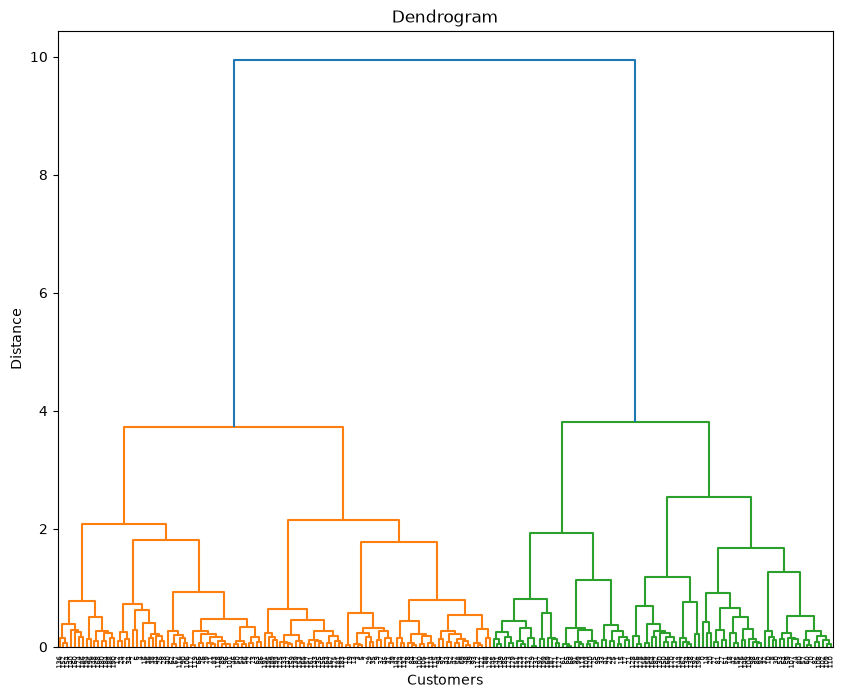

In [20]:
plt.figure(1, figsize = (10,8))
dendrogram = sch.dendrogram(sch.linkage(df, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

## 🚀 8. Hiyerarşik Kümeleme (4 küme) ve Görselleştirme / Hierarchical Clustering (4 clusters) & Visualization

**🇹🇷 Türkçe:**
`AgglomerativeClustering(n_clusters=4)`, ölçeklenmiş **4 özelliğin tamamı** (`Gender`, `Age`, `Annual Income`, `Spending Score`) üzerinde eğitiliyor ve `fit_predict` ile her müşteriye bir küme etiketi (`y_hc`) atanıyor. Bu etiket `df['cluster']` olarak DataFrame'e ekleniyor, ardından sonuç sadece iki boyutta (`Annual Income` vs `Spending Score`) görselleştiriliyor — kümeleme 4 boyutta yapılmış olsa da, grafik sadece bu ikisini gösterebiliyor.

**🇬🇧 English:**
`AgglomerativeClustering(n_clusters=4)` is trained on **all four scaled features** (`Gender`, `Age`, `Annual Income`, `Spending Score`), and `fit_predict` assigns each customer a cluster label (`y_hc`). This label is added to the DataFrame as `df['cluster']`, then the result is visualized in just two dimensions (`Annual Income` vs `Spending Score`) — even though clustering happened in 4D, the plot can only show these two.

In [21]:
from sklearn.cluster import AgglomerativeClustering

In [22]:
hc = AgglomerativeClustering(n_clusters=4)

In [23]:
y_hc = hc.fit_predict(df)

In [24]:
y_hc

array([0, 2, 3, 1, 3, 1, 3, 1, 0, 1, 0, 1, 3, 1, 0, 2, 3, 2, 0, 1, 0, 2,
       3, 2, 3, 2, 3, 0, 3, 1, 0, 1, 0, 2, 3, 1, 3, 1, 3, 1, 3, 2, 0, 1,
       3, 1, 3, 1, 1, 1, 3, 0, 1, 0, 3, 0, 3, 0, 1, 0, 0, 2, 3, 3, 0, 2,
       3, 3, 2, 1, 0, 3, 3, 3, 0, 2, 3, 0, 1, 3, 0, 0, 0, 3, 1, 0, 3, 1,
       1, 3, 3, 2, 0, 1, 1, 2, 3, 1, 0, 2, 1, 3, 0, 2, 0, 1, 3, 0, 0, 0,
       0, 1, 1, 2, 1, 1, 3, 3, 3, 3, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 0, 2,
       1, 1, 0, 1, 3, 2, 0, 1, 3, 2, 1, 1, 0, 2, 0, 1, 3, 2, 0, 2, 3, 1,
       3, 1, 0, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 1, 3, 2, 0, 2, 0, 2, 3, 1,
       0, 2, 0, 2, 3, 1, 0, 1, 3, 2, 3, 2, 3, 1, 3, 1, 0, 1, 3, 1, 3, 2,
       0, 2])

In [25]:
df['cluster'] = pd.DataFrame(y_hc)

In [26]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1.0,0.019231,0.000000,0.387755,0
1,1.0,0.057692,0.000000,0.816327,2
2,0.0,0.038462,0.008197,0.051020,3
3,0.0,0.096154,0.008197,0.775510,1
4,0.0,0.250000,0.016393,0.397959,3


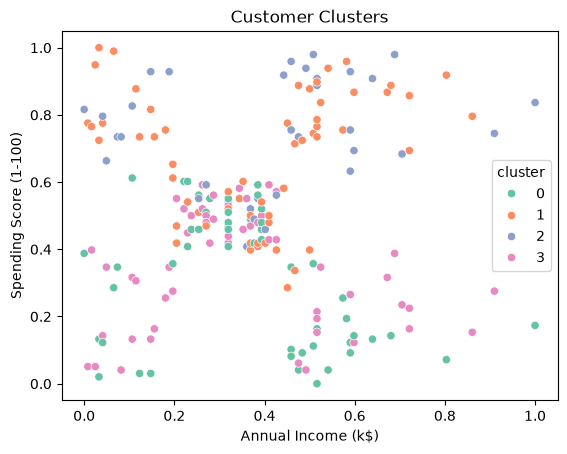

In [27]:
sns.scatterplot(data=df, x = "Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette = "Set2")
plt.title("Customer Clusters")
plt.show()

## ✅ 9. Silüet Skoru — Etiket Sızıntısı Düzeltildi / Silhouette Score — Label Leakage Fixed

**🇹🇷 Türkçe:**
Orijinal kod `silhouette_score(df, y_hc)` şeklindeydi; bu noktada `df`, kümeleme özellikleriyle (`Gender`, `Age`, `Annual Income`, `Spending Score`) birlikte az önce eklenen **`cluster` kolonunu da** içeriyordu. Yani skor, kümeleme sonucunun kendisini bir özellikmiş gibi mesafe hesabına dahil ederek hesaplanıyordu — `cluster` her noktayı kendi grubuyla neredeyse mükemmel ayırdığı için (0,1,2,3 gibi ayrık değerler) bu tek kolon mesafeleri domine edip skoru yapay şekilde şişiriyordu (eski, hatalı değer: 0.7143).

**Düzeltme:** `silhouette_score(df.drop(columns='cluster'), y_hc)` — sadece kümelemede kullanılan 4 özellik veriliyor, etiket dahil edilmiyor. Doğru (düzeltilmiş) silüet skoru: **0.3444** — eski şişirilmiş değerden belirgin şekilde düşük, bu da 4 özellikle (Gender+Age+Income+Spending) 4 kümenin aslında pek net ayrılmadığını gösteriyor.

**🇬🇧 English:**
The original code was `silhouette_score(df, y_hc)`; at that point `df` contained the clustering features (`Gender`, `Age`, `Annual Income`, `Spending Score`) plus the `cluster` column just added. So the score was computed with the clustering result folded into the distance calculation as if it were a feature — since `cluster` separates every point from its own group almost perfectly (discrete values 0,1,2,3), this one column dominated the distances and artificially inflated the score (old, buggy value: 0.7143).

**Fix:** `silhouette_score(df.drop(columns='cluster'), y_hc)` — only the 4 features used for clustering are passed, not the label. The correct (fixed) silhouette score is **0.3444** — noticeably lower than the old inflated value, showing that with 4 features (Gender+Age+Income+Spending) the 4 clusters aren't actually very well separated.

In [28]:
from sklearn.metrics import silhouette_score
print(silhouette_score(df.drop(columns='cluster'), y_hc))

0.3444266582171814


## 🔁 10. Sadece 2 Özellikle Yeniden Kümeleme (5 küme) / Re-clustering with Just 2 Features (5 clusters)

**🇹🇷 Türkçe:**
Bu kez sadece `Annual Income` ve `Spending Score` seçilerek yeni bir `X` oluşturuluyor (henüz `cluster` kolonu yok) ve `AgglomerativeClustering(n_clusters=5)` bu 2 boyutlu uzayda eğitiliyor — bu, mall_customers veri setinin klasik "5 müşteri segmenti" görselini üretiyor (düşük gelir/düşük harcama, yüksek gelir/yüksek harcama vb.).

**🇬🇧 English:**
This time only `Annual Income` and `Spending Score` are selected into a new `X` (no `cluster` column yet), and `AgglomerativeClustering(n_clusters=5)` is trained in this 2D space — producing the classic "5 customer segments" visual for the mall_customers dataset (low income/low spending, high income/high spending, etc.).

In [29]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]].copy()

In [30]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.387755
1,0.000000,0.816327
2,0.008197,0.051020
3,0.008197,0.775510
4,0.016393,0.397959


In [31]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X)
X['cluster'] = y_hc

In [32]:
X

,Annual Income (k$),Spending Score (1-100),cluster
0,0.000000,0.387755,4
1,0.000000,0.816327,3
2,0.008197,0.051020,4
3,0.008197,0.775510,3
4,0.016393,0.397959,4
...,...,...,...
195,0.860656,0.795918,0
196,0.909836,0.275510,2
197,0.909836,0.744898,0
198,1.000000,0.173469,2


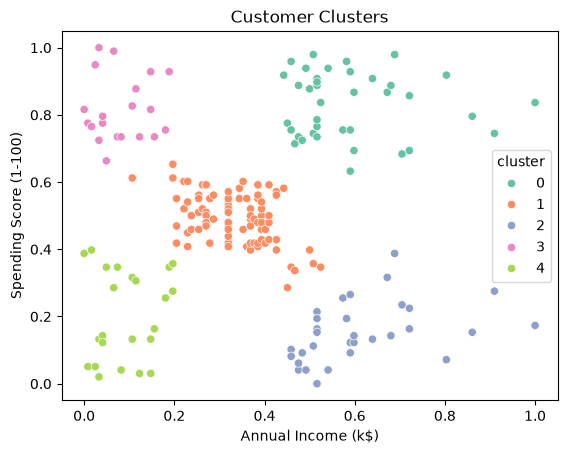

In [33]:
sns.scatterplot(data=X, x = "Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette = "Set2")
plt.title("Customer Clusters")
plt.show()

## ✅ 11. Aynı Sızıntı Burada da Düzeltildi / The Same Leak Fixed Here Too

**🇹🇷 Türkçe:**
Bir hücre önce (`bb4812de`) `X['cluster'] = y_hc` ile etiket `X`'e geri eklenmişti, dolayısıyla orijinal `silhouette_score(X, y_hc)` çağrısı aynı hatayı tekrarlıyordu — `X` burada `Annual Income`, `Spending Score` **ve `cluster`**'ı içeriyordu. Sadece 3 kolon olduğu için `cluster`'ın baskınlığı daha da güçlüydü ve eski (hatalı) skor 0.8508 gibi son derece yüksek bir değer veriyordu.

**Düzeltme:** `silhouette_score(X.drop(columns='cluster'), y_hc)` — sadece `Annual Income` ve `Spending Score` veriliyor. Doğru skor: **0.5583**. Bu değerin, notebook'un ilerisindeki "Sistematik Karşılaştırma" bölümündeki `features_2d` sonucuyla (0.558) birebir örtüşmesi mantıklı — ikisi de aynı iki özellik ve aynı `n_clusters=5` ile hesaplanıyor, sadece burada tüm veri üzerinde, orada ise taze okunmuş bir kopya üzerinde çalışılıyor.

**🇬🇧 English:**
One cell earlier (`bb4812de`), `X['cluster'] = y_hc` had added the label back into `X`, so the original `silhouette_score(X, y_hc)` call repeated the same mistake — `X` contained `Annual Income`, `Spending Score`, **and `cluster`**. With only 3 columns total, `cluster`'s dominance was even stronger, and the old (buggy) score came out at an inflated 0.8508.

**Fix:** `silhouette_score(X.drop(columns='cluster'), y_hc)` — only `Annual Income` and `Spending Score` are passed. The correct score is **0.5583**. It makes sense that this matches the `features_2d` result (0.558) from the "Systematic Comparison" section further down almost exactly — both use the same two features and the same `n_clusters=5`, just computed here on the full data vs. there on a freshly re-read copy.

In [34]:
print(silhouette_score(X.drop(columns='cluster'), y_hc))

0.5582698727196419


## ✅ 12. Sistematik Karşılaştırma — Bu Kez Doğru Yapılıyor / Systematic Comparison — Done Correctly This Time

**🇹🇷 Türkçe:**
Veri baştan temiz şekilde okunup (`cluster` kolonu olmadan) üç farklı özellik alt kümesi (`features_2d`, `features_3d`, `features_4d`) için döngü kuruluyor. Her adımda: `MinMaxScaler` **sadece o alt kümedeki** özelliklere uygulanıyor, `AgglomerativeClustering(n_clusters=5)` eğitiliyor, ve `silhouette_score`, `davies_bouldin_score`, `calinski_harabasz_score` **hep `X_scaled`** üzerinden hesaplanıyor — `cluster` etiketi hiçbir zaman özellik matrisine karışmıyor. Bu, yukarıdaki 9. ve 11. bölümlerdeki hatanın düzeltilmiş hali.

**Sonuç:** Sadece 2 özellik (`Annual Income`, `Spending Score`) kullanıldığında silüet skoru en yüksek (0.558), 3 ve 4 özellik eklendikçe skor düşüyor (0.396, 0.350) — Davies-Bouldin de aynı yönde (düşük=iyi, 0.573→1.094) ve Calinski-Harabasz da aynı yönde (yüksek=iyi, 259→123) bunu doğruluyor. Yani `Age` ve `Gender` eklemek, bu veri setinde kümeleri daha az değil **daha belirsiz** hale getiriyor — muhtemelen gelir/harcama zaten çok net beş grup oluşturuyor ve ek boyutlar bu net ayrımı "bulanıklaştırıyor".

**🇬🇧 English:**
The data is re-read cleanly (no `cluster` column), and a loop runs over three feature subsets (`features_2d`, `features_3d`, `features_4d`). At each step: `MinMaxScaler` is applied **only to that subset's** features, `AgglomerativeClustering(n_clusters=5)` is trained, and `silhouette_score`, `davies_bouldin_score`, `calinski_harabasz_score` are all computed on **`X_scaled`** — the `cluster` label never leaks into the feature matrix. This is the corrected version of the bug from sections 9 and 11 above.

**Result:** Using just 2 features (`Annual Income`, `Spending Score`) gives the highest silhouette score (0.558); adding the 3rd and 4th feature makes it drop (0.396, 0.350) — Davies-Bouldin agrees (lower=better, 0.573→1.094) and so does Calinski-Harabasz (higher=better, 259→123). So adding `Age` and `Gender` makes clusters **less** well-defined in this dataset, not more — likely because income/spending alone already forms five clean groups, and the extra dimensions blur that clean separation.

In [35]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [36]:
df = pd.read_csv("../../Data/27-mall_customers.csv")
df = df.drop("CustomerID", axis = 1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features_2d = ["Annual Income (k$)","Spending Score (1-100)"]
features_3d = ["Age","Annual Income (k$)","Spending Score (1-100)"]
features_4d = ["Gender","Age","Annual Income (k$)","Spending Score (1-100)"]

for feats in [features_2d,features_3d,features_4d]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters=5)
    y_hc = hc.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, y_hc)
    db = davies_bouldin_score(X_scaled, y_hc)
    ch = calinski_harabasz_score(X_scaled, y_hc)

    
    print(f"\n features :{feats}")
    print("Silhoutte score: ", sil)
    print("Davies Bouldin score: ", db)
    print("Calinski Harabasz score: ", ch)
    print("-------------")


 features :['Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.5582698727196419
Davies Bouldin score:  0.5734519252471811
Calinski Harabasz score:  258.97400737720704
-------------

 features :['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.3955454334726547
Davies Bouldin score:  0.8746143334035464
Calinski Harabasz score:  123.99070840826577
-------------

 features :['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.35032447507156306
Davies Bouldin score:  1.0941951795238571
Calinski Harabasz score:  163.46602356383625
-------------


In [37]:
from sklearn.cluster import KMeans

In [38]:
df = pd.read_csv("../../Data/27-mall_customers.csv")
df = df.drop("CustomerID", axis = 1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features_2d = ["Annual Income (k$)","Spending Score (1-100)"]
features_3d = ["Age","Annual Income (k$)","Spending Score (1-100)"]
features_4d = ["Gender","Age","Annual Income (k$)","Spending Score (1-100)"]

for feats in [features_2d,features_3d,features_4d]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=5)
    y_hc = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, y_hc)
    db = davies_bouldin_score(X_scaled, y_hc)
    ch = calinski_harabasz_score(X_scaled, y_hc)

    
    print(f"\n features :{feats}")
    print("Silhoutte score: ", sil)
    print("Davies Bouldin score: ", db)
    print("Calinski Harabasz score: ", ch)
    print("-------------")


 features :['Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.5602436353739457
Davies Bouldin score:  0.5630236200163117
Calinski Harabasz score:  264.70156956422267
-------------

 features :['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.40799092662481257
Davies Bouldin score:  0.8844907887102462
Calinski Harabasz score:  127.83113685313914
-------------

 features :['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.39584078500950304
Davies Bouldin score:  0.9265721756415186
Calinski Harabasz score:  116.35634545200658
-------------
